# Hail M0 - MYRORSS Source Qualification - Selected-Cell Batch Contract

**Peril:** hail - **Layer:** M0 input evidence - **Mode:** common source qualification with a
CONUS-grid selected-cell adapter proof

This notebook is the widening step after `02_selected_cell_record_scan`. It keeps the selected-cell scope,
but changes the denominator from a few report-guided stress dates to a chronological MYRORSS batch.

## Step back - why this notebook exists

The current source ladder is:

```text
01_myrorss_meet_data
  -> understand one MYRORSS day and sparse-grid decoding

02_selected_cell_record_scan
  -> report-guided stress dates
  -> proves exact-cell + 3x3-neighborhood scanner QA
  -> not a frequency sample

03_selected_cell_full_record_batches
  -> chronological MYRORSS date batches
  -> explicit zero/no-data days
  -> same selected-cell daily evidence contract
  -> source-era summaries only after enough batches are complete
```

Source roles stay strict:

- **MYRORSS:** gridded evidence source for the 1998-2011 older radar-reanalysis era.
- **NOAA Storm Events / SPC:** validation and date context only; not used to choose this batch.
- **MRMS:** later operational-era comparison source; not blended here.
- **NRI:** downstream sanity check only; not an M1 input.

Full-record scanning is file-count dominated. MYRORSS does not provide a cell-level spatial index, so even
for four selected cells we still have to inspect every MESH file in each scanned day. That is why this
notebook is explicitly batched and resumable by raw-byte cache. A small default proof batch is executed
first; wider runs should set `MYRORSS_BATCH_START` and `MYRORSS_BATCH_END`.

Plan links:

- `docs/plans/hazard_conus_grid/hail/m0_m1_hazard_layer.md`
- `docs/extra/discussion/conus_grid/hail/01_m1_sourcing_triage.md`
- `docs/principles/notebook_work/exploratory_data_notebooks.md`

## 0 - Scope and non-goals

This notebook does:

1. Load the four locked selected cells.
2. Build a full-record chronological batch plan for the MYRORSS-era candidate window.
3. Execute one configurable date batch.
4. Materialize one selected-cell row per date, including zero/no-data days.
5. Preserve exact-cell and 3x3-neighborhood diagnostics.
6. Write batch panel, summary, day manifest, batch plan, and metadata artifacts.

It deliberately does **not**:

- finish the entire 1998-2011 record in one interactive run;
- use NOAA reports to select dates;
- merge MYRORSS with MRMS;
- estimate final annual `lambda_cell`;
- bias-correct MESH;
- fit the tail;
- produce EAL, VaR, PML, or TVaR.

The carried-forward object is a **chronological MYRORSS selected-cell batch**, not a final M1 hail
climatology.

In [1]:
from __future__ import annotations

import gzip
import json
import os
import time
import tempfile
import xml.etree.ElementTree as ET
from dataclasses import dataclass
from pathlib import Path
from urllib.parse import quote

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import xarray as xr
from IPython.display import display

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 115})


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root not found")


ROOT = _repo_root()
HAIL_GRID_DIR = ROOT / "data" / "hazard_conus_grid" / "hail"
RAW_MYRORSS_DIR = HAIL_GRID_DIR / "raw_myrorss"
RAW_MYRORSS_DIR.mkdir(parents=True, exist_ok=True)

SELECTED_CELLS_CSV = HAIL_GRID_DIR / "selected_pilot_cells_v2026_06_16.csv"

OUTPUT_VERSION = "v2026_06_16"
SEVERE_HAIL_MM = 25.4

# The first verified MESH day in quick source checks is 1998-05-01. If a later source-availability index
# proves earlier valid MESH days, extend this candidate window explicitly.
FULL_RECORD_CANDIDATE_START = pd.Timestamp("1998-05-01")
FULL_RECORD_CANDIDATE_END = pd.Timestamp("2011-12-31")

DEFAULT_BATCH_START = "1998-05-01"
DEFAULT_BATCH_END = "1998-05-02"
BATCH_START = pd.Timestamp(os.environ.get("MYRORSS_BATCH_START", DEFAULT_BATCH_START))
BATCH_END = pd.Timestamp(os.environ.get("MYRORSS_BATCH_END", DEFAULT_BATCH_END))
BATCH_DAYS_FOR_PLAN = int(os.environ.get("MYRORSS_BATCH_PLAN_DAYS", "14"))

if BATCH_END < BATCH_START:
    raise ValueError("MYRORSS_BATCH_END must be on or after MYRORSS_BATCH_START")

BATCH_LABEL = f"{BATCH_START:%Y%m%d}_{BATCH_END:%Y%m%d}"
BATCH_DATE_RANGE = pd.date_range(BATCH_START, BATCH_END, freq="D")

BATCH_PLAN_CSV = HAIL_GRID_DIR / f"myrorss_m0_selected_cell_full_record_batch_plan_{OUTPUT_VERSION}.csv"
DAY_MANIFEST_CSV = (
    HAIL_GRID_DIR / f"myrorss_m0_selected_cell_full_record_day_manifest_{BATCH_LABEL}_{OUTPUT_VERSION}.csv"
)
DAILY_PANEL_CSV = (
    HAIL_GRID_DIR / f"myrorss_m0_selected_cell_full_record_daily_panel_{BATCH_LABEL}_{OUTPUT_VERSION}.csv"
)
SUMMARY_CSV = HAIL_GRID_DIR / f"myrorss_m0_selected_cell_full_record_summary_{BATCH_LABEL}_{OUTPUT_VERSION}.csv"
METADATA_JSON = HAIL_GRID_DIR / f"myrorss_m0_selected_cell_full_record_metadata_{BATCH_LABEL}_{OUTPUT_VERSION}.json"

print("repo root:", ROOT)
print("selected cells:", SELECTED_CELLS_CSV.relative_to(ROOT))
print("MYRORSS raw cache:", RAW_MYRORSS_DIR.relative_to(ROOT))
print("batch window:", BATCH_START.date(), "to", BATCH_END.date(), f"({len(BATCH_DATE_RANGE)} days)")
print("severe hail threshold:", SEVERE_HAIL_MM, "mm")

repo root: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling
selected cells: data/hazard_conus_grid/hail/selected_pilot_cells_v2026_06_16.csv
MYRORSS raw cache: data/hazard_conus_grid/hail/raw_myrorss
batch window: 1998-05-29 to 1998-06-11 (14 days)
severe hail threshold: 25.4 mm


## 1 - Date-window controls and batch plan

This notebook has two date concepts:

| Date concept | Meaning | Use |
|---|---|---|
| Full-record candidate window | Current working window for MYRORSS MESH evidence | Used to create a batch plan. |
| Execution batch window | The dates actually scanned in this run | Used to write dated batch artifacts. |

The default execution batch is intentionally small so the notebook can be run and inspected. Wider runs
should be launched by setting environment variables, for example:

```bash
MYRORSS_BATCH_START=1998-05-01 MYRORSS_BATCH_END=1998-05-14 \
  .venv/bin/jupyter nbconvert --execute --to notebook --inplace \
  Notebooks/hail/m0_input_data/03_myrorss_reanalysis_source_qualification/03_selected_cell_full_record_batches.ipynb
```

In [2]:
date_controls = pd.DataFrame(
    [
        (
            "full_record_candidate_window",
            FULL_RECORD_CANDIDATE_START.date().isoformat(),
            FULL_RECORD_CANDIDATE_END.date().isoformat(),
            "working MYRORSS MESH window; extend only after source-availability check",
        ),
        (
            "execution_batch_window",
            BATCH_START.date().isoformat(),
            BATCH_END.date().isoformat(),
            "dates scanned in this notebook run",
        ),
        (
            "default_proof_batch",
            DEFAULT_BATCH_START,
            DEFAULT_BATCH_END,
            "small chronological proof batch; not report-guided",
        ),
    ],
    columns=["window", "start", "end", "meaning"],
)
display(date_controls)


def make_batch_plan(start: pd.Timestamp, end: pd.Timestamp, batch_days: int) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    dates = pd.date_range(start, end, freq="D")
    for batch_idx, offset in enumerate(range(0, len(dates), batch_days), start=1):
        batch_dates = dates[offset : offset + batch_days]
        rows.append(
            {
                "batch_id": f"myrorss_selected_cell_{batch_idx:04d}",
                "batch_start": batch_dates[0].date().isoformat(),
                "batch_end": batch_dates[-1].date().isoformat(),
                "n_days": int(len(batch_dates)),
                "source": "MYRORSS",
                "source_product": "MESH/00.25",
                "planned_role": "chronological selected-cell batch",
                "allowed_use": "batch execution plan; not a data output",
            }
        )
    return pd.DataFrame(rows)


batch_plan = make_batch_plan(FULL_RECORD_CANDIDATE_START, FULL_RECORD_CANDIDATE_END, BATCH_DAYS_FOR_PLAN)
batch_plan.to_csv(BATCH_PLAN_CSV, index=False)
display(batch_plan.head(8))
print("planned batches:", len(batch_plan), "at", BATCH_DAYS_FOR_PLAN, "days per batch")
print("wrote batch plan:", BATCH_PLAN_CSV.relative_to(ROOT))

,window,start,end,meaning
0,full_record_candidate_window,1998-05-01,2011-12-31,working MYRORSS MESH window; extend only after...
1,execution_batch_window,1998-05-29,1998-06-11,dates scanned in this notebook run
2,default_proof_batch,1998-05-01,1998-05-02,small chronological proof batch; not report-gu...


,batch_id,batch_start,batch_end,n_days,source,source_product,planned_role,allowed_use
0,myrorss_selected_cell_0001,1998-05-01,1998-05-14,14,MYRORSS,MESH/00.25,chronological selected-cell batch,batch execution plan; not a data output
1,myrorss_selected_cell_0002,1998-05-15,1998-05-28,14,MYRORSS,MESH/00.25,chronological selected-cell batch,batch execution plan; not a data output
2,myrorss_selected_cell_0003,1998-05-29,1998-06-11,14,MYRORSS,MESH/00.25,chronological selected-cell batch,batch execution plan; not a data output
3,myrorss_selected_cell_0004,1998-06-12,1998-06-25,14,MYRORSS,MESH/00.25,chronological selected-cell batch,batch execution plan; not a data output
4,myrorss_selected_cell_0005,1998-06-26,1998-07-09,14,MYRORSS,MESH/00.25,chronological selected-cell batch,batch execution plan; not a data output
5,myrorss_selected_cell_0006,1998-07-10,1998-07-23,14,MYRORSS,MESH/00.25,chronological selected-cell batch,batch execution plan; not a data output
6,myrorss_selected_cell_0007,1998-07-24,1998-08-06,14,MYRORSS,MESH/00.25,chronological selected-cell batch,batch execution plan; not a data output
7,myrorss_selected_cell_0008,1998-08-07,1998-08-20,14,MYRORSS,MESH/00.25,chronological selected-cell batch,batch execution plan; not a data output


planned batches: 357 at 14 days per batch
wrote batch plan: data/hazard_conus_grid/hail/myrorss_m0_selected_cell_full_record_batch_plan_v2026_06_16.csv


**Takeaway.** The widening path is explicit: run chronological batches and append/reconcile them later.
The default proof batch is not evidence of the full record; it only proves the batch contract.

## 2 - Load selected cells and 3x3 neighborhood targets

The selected-cell manifest is the durable input. Candidate files and report-QA files remain provenance.

In [3]:
selected_cells = pd.read_csv(SELECTED_CELLS_CSV)
selected_cells = selected_cells[
    [
        "hazard",
        "selection_version",
        "role",
        "cell_id",
        "lat_center",
        "lon_center",
        "state_abbr",
        "iso_rto",
        "allowed_use",
        "not_allowed_use",
    ]
].copy()
selected_cells["cell_id"] = selected_cells["cell_id"].astype(int)
selected_ids = set(selected_cells["cell_id"])


def neighbor_cell_ids_3x3(cell_id: int) -> list[int]:
    lat_idx = int(cell_id) // 1440
    lon_idx = int(cell_id) % 1440
    ids: list[int] = []
    for d_lat in (-1, 0, 1):
        for d_lon in (-1, 0, 1):
            n_lat = lat_idx + d_lat
            n_lon = (lon_idx + d_lon) % 1440
            if 0 <= n_lat < 720:
                ids.append(n_lat * 1440 + n_lon)
    return sorted(set(ids))


neighbor_map = {
    int(row.cell_id): neighbor_cell_ids_3x3(int(row.cell_id))
    for row in selected_cells.itertuples(index=False)
}
scan_target_ids = set().union(*neighbor_map.values())

neighbor_manifest = pd.DataFrame(
    [
        {
            "role": row.role,
            "cell_id": int(row.cell_id),
            "neighbor_3x3_cell_ids": ",".join(str(x) for x in neighbor_map[int(row.cell_id)]),
            "n_neighbor_3x3_cells": len(neighbor_map[int(row.cell_id)]),
        }
        for row in selected_cells.itertuples(index=False)
    ]
)

display(selected_cells)
display(neighbor_manifest)
print("selected cells:", len(selected_ids))
print("scan target cells including 3x3 neighborhoods:", len(scan_target_ids))

,hazard,selection_version,role,cell_id,lat_center,lon_center,state_abbr,iso_rto,allowed_use,not_allowed_use
0,hail,v2026_06_16,high_hail,329354,33.00,-101.50,TX,ERCOT,selected-cell M1 pilot only,not production CONUS hail climatology; not fin...
1,hail,v2026_06_16,medium_hail,261700,44.75,-95.00,MN,MISO,selected-cell M1 pilot only,not production CONUS hail climatology; not fin...
2,hail,v2026_06_16,low_hail,247197,47.25,-120.75,WA,WEIM,selected-cell M1 pilot only,not production CONUS hail climatology; not fin...
3,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,selected-cell M1 pilot only,not production CONUS hail climatology; not fin...


,role,cell_id,neighbor_3x3_cell_ids,n_neighbor_3x3_cells
0,high_hail,329354,"327913,327914,327915,329353,329354,329355,3307...",9
1,medium_hail,261700,"260259,260260,260261,261699,261700,261701,2631...",9
2,low_hail,247197,"245756,245757,245758,247196,247197,247198,2486...",9
3,hayhurst_reference,336544,"335103,335104,335105,336543,336544,336545,3379...",9


selected cells: 4
scan target cells including 3x3 neighborhoods: 36


## 3 - Field contract

The fields are designed to line up with the MRMS selected-cell daily panel while preserving MYRORSS-specific
source QA. MYRORSS sparse pixels are not a dense coverage denominator, so fields named `positive_*` are
source-support counts, not area coverage.

In [4]:
field_contract = pd.DataFrame(
    [
        ("date", "MYRORSS calendar day scanned", "date", "daily panel key"),
        ("cell_id", "benchmark grid key", "integer", "selected-cell identity"),
        ("n_source_files", "MESH files listed under the day prefix", "file count", "source coverage/provenance"),
        ("n_empty_source_files", "listed source files with zero bytes", "file count", "source QA"),
        ("n_read_failures", "source files that could not be decoded", "file count", "source QA"),
        ("positive_native_pixel_records", "sparse MYRORSS pixels in selected cell", "record count", "support indicator, not denominator"),
        ("severe_native_pixel_records", "selected-cell sparse pixels with MESH >= 25.4 mm", "record count", "severe support indicator"),
        ("mesh_max_mm", "daily maximum selected-cell MYRORSS MESH", "mm", "conditional size evidence"),
        ("hail_day_flag", "any selected-cell severe MYRORSS pixel on that day", "boolean", "daily severe flag for this source"),
        ("coverage_status", "listed/no sparse/subsevere/severe/failure status", "category", "prevents silent zeros"),
        ("neighbor_3x3_*", "same-day evidence in selected cell plus adjacent 8 cells", "counts and mm", "QA context only"),
        ("batch_label", "execution window id", "YYYYMMDD_YYYYMMDD", "rebuild/reconciliation key"),
    ],
    columns=["field", "what it is", "units / base", "how we use it"],
)
display(field_contract)

,field,what it is,units / base,how we use it
0,date,MYRORSS calendar day scanned,date,daily panel key
1,cell_id,benchmark grid key,integer,selected-cell identity
2,n_source_files,MESH files listed under the day prefix,file count,source coverage/provenance
3,n_empty_source_files,listed source files with zero bytes,file count,source QA
4,n_read_failures,source files that could not be decoded,file count,source QA
5,positive_native_pixel_records,sparse MYRORSS pixels in selected cell,record count,"support indicator, not denominator"
6,severe_native_pixel_records,selected-cell sparse pixels with MESH >= 25.4 mm,record count,severe support indicator
7,mesh_max_mm,daily maximum selected-cell MYRORSS MESH,mm,conditional size evidence
8,hail_day_flag,any selected-cell severe MYRORSS pixel on that...,boolean,daily severe flag for this source
9,coverage_status,listed/no sparse/subsevere/severe/failure status,category,prevents silent zeros


**Takeaway.** The batch panel can later feed M1 only after enough chronological batches exist and after
source-homogeneity/bias checks. A one-batch hail-day fraction is not a final frequency estimate.

## 4 - MYRORSS sparse-grid client and scanner

Raw source bytes are cached under `data/hazard_conus_grid/hail/raw_myrorss/`, which is gitignored. That
cache is the main resumability mechanism: re-running a batch reuses already-downloaded source files.

In [5]:
@dataclass
class MYRORSSClient:
    root_url: str = "https://noaa-oar-myrorss-pds.s3.amazonaws.com"
    cache_dir: Path = RAW_MYRORSS_DIR
    namespace: str = "{http://s3.amazonaws.com/doc/2006-03-01/}"

    def list_keys(self, prefix: str) -> list[str]:
        keys: list[str] = []
        token: str | None = None
        while True:
            params = {"list-type": "2", "prefix": prefix, "max-keys": "1000"}
            if token:
                params["continuation-token"] = token
            response = requests.get(self.root_url + "/", params=params, timeout=60)
            response.raise_for_status()
            root = ET.fromstring(response.content)
            keys.extend(
                node.find(self.namespace + "Key").text
                for node in root.findall(self.namespace + "Contents")
            )
            next_token = root.find(self.namespace + "NextContinuationToken")
            if next_token is None:
                break
            token = next_token.text
        return sorted(keys)

    def cache_path(self, key: str) -> Path:
        return self.cache_dir / key.replace("/", "__")

    def fetch(self, key: str) -> Path:
        local = self.cache_path(key)
        if not local.exists():
            last_exc: Exception | None = None
            for attempt in range(1, 4):
                try:
                    response = requests.get(f"{self.root_url}/{quote(key)}", timeout=120)
                    response.raise_for_status()
                    local.write_bytes(response.content)
                    break
                except requests.HTTPError as exc:
                    last_exc = exc
                    status_code = exc.response.status_code if exc.response is not None else None
                    if status_code not in {429, 500, 502, 503, 504} or attempt == 3:
                        raise
                    time.sleep(2 * attempt)
                except requests.RequestException as exc:
                    last_exc = exc
                    if attempt == 3:
                        raise
                    time.sleep(2 * attempt)
            if not local.exists() and last_exc is not None:
                raise last_exc
        return local

    @staticmethod
    def open_dataset(local_path: Path) -> xr.Dataset:
        raw = local_path.read_bytes()
        if local_path.name.endswith(".gz"):
            raw = gzip.decompress(raw)
        with tempfile.NamedTemporaryFile(suffix=".netcdf") as tmp:
            tmp.write(raw)
            tmp.flush()
            return xr.open_dataset(tmp.name).load()


def sparse_points_for_target_cells(ds: xr.Dataset, target_cell_ids: set[int]) -> pd.DataFrame:
    mesh = ds["MESH"].values.astype(float)
    pixel_x = ds["pixel_x"].values.astype(float)
    pixel_y = ds["pixel_y"].values.astype(float)

    lat = float(ds.attrs["Latitude"]) - pixel_y * float(ds.attrs["LatGridSpacing"])
    lon = float(ds.attrs["Longitude"]) + pixel_x * float(ds.attrs["LonGridSpacing"])
    lat_idx = np.floor((90.0 - lat) / 0.25).astype(int)
    lon_idx = np.floor(np.mod(lon, 360.0) / 0.25).astype(int)
    cell_id = lat_idx * 1440 + lon_idx

    mask = np.isin(cell_id, np.array(sorted(target_cell_ids), dtype=np.int64))
    if not mask.any():
        return pd.DataFrame(columns=["cell_id", "mesh_mm", "timestamp_utc"])

    timestamp = pd.to_datetime(int(ds.attrs["Time"]), unit="s", utc=True)
    return pd.DataFrame(
        {
            "cell_id": cell_id[mask].astype(int),
            "mesh_mm": mesh[mask].astype(float),
            "timestamp_utc": timestamp,
        }
    )


def empty_stats_for_cell() -> dict[str, object]:
    return {
        "positive_native_pixel_records": 0,
        "severe_native_pixel_records": 0,
        "n_timestamps_with_positive_mesh": 0,
        "n_timestamps_with_severe_mesh": 0,
        "mesh_values": [],
        "severe_mesh_values": [],
        "first_timestamp_utc": None,
        "last_timestamp_utc": None,
    }


def scan_one_day(date: pd.Timestamp | str, target_cell_ids: set[int], client: MYRORSSClient) -> tuple[pd.DataFrame, dict]:
    date = pd.Timestamp(date)
    prefix = date.strftime("%Y/%m/%d/MESH/00.25/")
    keys = client.list_keys(prefix)

    stats = {int(cell_id): empty_stats_for_cell() for cell_id in target_cell_ids}
    failures: list[str] = []
    empty_files: list[str] = []

    for i, key in enumerate(keys, start=1):
        try:
            local_path = client.fetch(key)
            if local_path.stat().st_size == 0:
                empty_files.append(key)
                continue
            ds = client.open_dataset(local_path)
            points = sparse_points_for_target_cells(ds, target_cell_ids)
        except Exception as exc:  # noqa: BLE001 - notebook records source-read failures explicitly
            failures.append(f"{key}: {type(exc).__name__}: {exc}")
            continue

        if points.empty:
            continue

        points["is_severe"] = points["mesh_mm"] >= SEVERE_HAIL_MM
        for cell_id, group in points.groupby("cell_id"):
            cell = stats[int(cell_id)]
            values = group["mesh_mm"].astype(float).tolist()
            severe_values = group.loc[group["is_severe"], "mesh_mm"].astype(float).tolist()
            timestamp = group["timestamp_utc"].iloc[0]

            cell["positive_native_pixel_records"] += len(values)
            cell["severe_native_pixel_records"] += len(severe_values)
            cell["n_timestamps_with_positive_mesh"] += 1
            if severe_values:
                cell["n_timestamps_with_severe_mesh"] += 1
            cell["mesh_values"].extend(values)
            cell["severe_mesh_values"].extend(severe_values)
            cell["first_timestamp_utc"] = (
                timestamp if cell["first_timestamp_utc"] is None else min(cell["first_timestamp_utc"], timestamp)
            )
            cell["last_timestamp_utc"] = (
                timestamp if cell["last_timestamp_utc"] is None else max(cell["last_timestamp_utc"], timestamp)
            )

        if i % 100 == 0:
            print(f"{date.date()} processed {i:,} / {len(keys):,} MYRORSS files")

    rows: list[dict[str, object]] = []
    for cell_id, cell in stats.items():
        mesh_values = np.array(cell.pop("mesh_values"), dtype=float)
        severe_values = np.array(cell.pop("severe_mesh_values"), dtype=float)

        if len(keys) == 0:
            coverage_status = "source_day_not_listed"
        elif failures and len(failures) == len(keys):
            coverage_status = "source_files_all_failed"
        elif mesh_values.size == 0:
            coverage_status = "source_files_available_no_sparse_mesh_pixel"
        elif severe_values.size == 0:
            coverage_status = "source_files_available_sparse_mesh_seen_subsevere"
        else:
            coverage_status = "source_files_available_severe_mesh_seen"

        rows.append(
            {
                "date": date.date().isoformat(),
                "cell_id": int(cell_id),
                "source": "MYRORSS",
                "source_product": "MESH/00.25",
                "threshold_mm": SEVERE_HAIL_MM,
                "n_source_files": len(keys),
                "n_empty_source_files": len(empty_files),
                "n_read_failures": len(failures),
                **cell,
                "mesh_max_mm": float(np.nanmax(mesh_values)) if mesh_values.size else np.nan,
                "mesh_mean_seen_values_mm": float(np.nanmean(mesh_values)) if mesh_values.size else np.nan,
                "mesh_p50_seen_values_mm": float(np.nanquantile(mesh_values, 0.50)) if mesh_values.size else np.nan,
                "mesh_p90_seen_values_mm": float(np.nanquantile(mesh_values, 0.90)) if mesh_values.size else np.nan,
                "mesh_p95_seen_values_mm": float(np.nanquantile(mesh_values, 0.95)) if mesh_values.size else np.nan,
                "mesh_mean_severe_mm": float(np.nanmean(severe_values)) if severe_values.size else np.nan,
                "hail_day_flag": bool(severe_values.size > 0),
                "coverage_status": coverage_status,
                "read_failure_examples": " | ".join(failures[:3]),
            }
        )

    meta = {
        "date": date.date().isoformat(),
        "prefix": prefix,
        "n_source_files": len(keys),
        "n_empty_source_files": len(empty_files),
        "n_read_failures": len(failures),
        "empty_file_examples": empty_files[:3],
        "first_key": keys[0] if keys else None,
        "last_key": keys[-1] if keys else None,
    }
    return pd.DataFrame(rows), meta


myrorss = MYRORSSClient()

## 5 - Execute chronological batch

This is the expensive cell. It lists and scans every MYRORSS MESH file under each date in the execution
window, then extracts only sparse pixels inside the selected cells and their 3x3 neighborhoods.

In [6]:
day_frames: list[pd.DataFrame] = []
day_meta: list[dict] = []

for date in BATCH_DATE_RANGE:
    print("\nscanning MYRORSS date:", date.date())
    frame, meta = scan_one_day(date, scan_target_ids, myrorss)
    day_frames.append(frame)
    day_meta.append(meta)

scan_panel_all_targets = pd.concat(day_frames, ignore_index=True)
day_manifest = pd.DataFrame(day_meta)
day_manifest["batch_label"] = BATCH_LABEL
day_manifest["batch_start"] = BATCH_START.date().isoformat()
day_manifest["batch_end"] = BATCH_END.date().isoformat()

display(day_manifest)
display(scan_panel_all_targets.head(12))


scanning MYRORSS date: 1998-05-29



scanning MYRORSS date: 1998-05-30



scanning MYRORSS date: 1998-05-31



scanning MYRORSS date: 1998-06-01



scanning MYRORSS date: 1998-06-02


...


scanning MYRORSS date: 1998-06-09



scanning MYRORSS date: 1998-06-10



scanning MYRORSS date: 1998-06-11


,date,prefix,n_source_files,n_empty_source_files,n_read_failures,empty_file_examples,first_key,last_key,batch_label,batch_start,batch_end
0,1998-05-29,1998/05/29/MESH/00.25/,296,0,0,[],1998/05/29/MESH/00.25/19980529-113501.netcdf,1998/05/29/MESH/00.25/19980530-120746.netcdf,19980529_19980611,1998-05-29,1998-06-11
1,1998-05-30,1998/05/30/MESH/00.25/,296,0,0,[],1998/05/30/MESH/00.25/19980530-113502.netcdf,1998/05/30/MESH/00.25/19980531-120810.netcdf,19980529_19980611,1998-05-29,1998-06-11
2,1998-05-31,1998/05/31/MESH/00.25/,296,0,0,[],1998/05/31/MESH/00.25/19980531-113502.netcdf,1998/05/31/MESH/00.25/19980601-120810.netcdf,19980529_19980611,1998-05-29,1998-06-11
3,1998-06-01,1998/06/01/MESH/00.25/,296,0,0,[],1998/06/01/MESH/00.25/19980601-113501.netcdf,1998/06/01/MESH/00.25/19980602-120811.netcdf,19980529_19980611,1998-05-29,1998-06-11
4,1998-06-02,1998/06/02/MESH/00.25/,296,0,0,[],1998/06/02/MESH/00.25/19980602-113501.netcdf,1998/06/02/MESH/00.25/19980603-120726.netcdf,19980529_19980611,1998-05-29,1998-06-11
5,1998-06-03,1998/06/03/MESH/00.25/,296,0,0,[],1998/06/03/MESH/00.25/19980603-113511.netcdf,1998/06/03/MESH/00.25/19980604-120755.netcdf,19980529_19980611,1998-05-29,1998-06-11
6,1998-06-04,1998/06/04/MESH/00.25/,296,0,0,[],1998/06/04/MESH/00.25/19980604-113501.netcdf,1998/06/04/MESH/00.25/19980605-120815.netcdf,19980529_19980611,1998-05-29,1998-06-11
7,1998-06-05,1998/06/05/MESH/00.25/,296,0,0,[],1998/06/05/MESH/00.25/19980605-113509.netcdf,1998/06/05/MESH/00.25/19980606-120759.netcdf,19980529_19980611,1998-05-29,1998-06-11
8,1998-06-06,1998/06/06/MESH/00.25/,296,0,0,[],1998/06/06/MESH/00.25/19980606-113510.netcdf,1998/06/06/MESH/00.25/19980607-120804.netcdf,19980529_19980611,1998-05-29,1998-06-11
9,1998-06-07,1998/06/07/MESH/00.25/,296,0,0,[],1998/06/07/MESH/00.25/19980607-113507.netcdf,1998/06/07/MESH/00.25/19980608-120804.netcdf,19980529_19980611,1998-05-29,1998-06-11


,date,cell_id,source,source_product,threshold_mm,n_source_files,n_empty_source_files,n_read_failures,positive_native_pixel_records,severe_native_pixel_records,...,last_timestamp_utc,mesh_max_mm,mesh_mean_seen_values_mm,mesh_p50_seen_values_mm,mesh_p90_seen_values_mm,mesh_p95_seen_values_mm,mesh_mean_severe_mm,hail_day_flag,coverage_status,read_failure_examples
0,1998-05-29,335104,MYRORSS,MESH/00.25,25.4,296,0,0,0,0,...,None,NaN,NaN,NaN,NaN,NaN,NaN,False,source_files_available_no_sparse_mesh_pixel,
1,1998-05-29,335105,MYRORSS,MESH/00.25,25.4,296,0,0,0,0,...,None,NaN,NaN,NaN,NaN,NaN,NaN,False,source_files_available_no_sparse_mesh_pixel,
2,1998-05-29,329353,MYRORSS,MESH/00.25,25.4,296,0,0,0,0,...,None,NaN,NaN,NaN,NaN,NaN,NaN,False,source_files_available_no_sparse_mesh_pixel,
3,1998-05-29,329354,MYRORSS,MESH/00.25,25.4,296,0,0,0,0,...,None,NaN,NaN,NaN,NaN,NaN,NaN,False,source_files_available_no_sparse_mesh_pixel,
4,1998-05-29,329355,MYRORSS,MESH/00.25,25.4,296,0,0,0,0,...,None,NaN,NaN,NaN,NaN,NaN,NaN,False,source_files_available_no_sparse_mesh_pixel,
5,1998-05-29,247196,MYRORSS,MESH/00.25,25.4,296,0,0,0,0,...,None,NaN,NaN,NaN,NaN,NaN,NaN,False,source_files_available_no_sparse_mesh_pixel,
6,1998-05-29,247197,MYRORSS,MESH/00.25,25.4,296,0,0,0,0,...,None,NaN,NaN,NaN,NaN,NaN,NaN,False,source_files_available_no_sparse_mesh_pixel,
7,1998-05-29,247198,MYRORSS,MESH/00.25,25.4,296,0,0,0,0,...,None,NaN,NaN,NaN,NaN,NaN,NaN,False,source_files_available_no_sparse_mesh_pixel,
8,1998-05-29,336543,MYRORSS,MESH/00.25,25.4,296,0,0,0,0,...,None,NaN,NaN,NaN,NaN,NaN,NaN,False,source_files_available_no_sparse_mesh_pixel,
9,1998-05-29,336544,MYRORSS,MESH/00.25,25.4,296,0,0,0,0,...,None,NaN,NaN,NaN,NaN,NaN,NaN,False,source_files_available_no_sparse_mesh_pixel,


**Takeaway.** Each scanned day now has a source-file manifest and explicit rows for all selected-cell
neighborhood targets. No sparse pixel is different from no source files, and the panel keeps those states
separate.

## 6 - Build selected-cell panel with neighborhood QA

The durable batch output is selected-cell x date. The 3x3 neighborhood stays attached as QA context only;
it does not redefine the selected-cell hail-day flag.

In [7]:
scan_panel = scan_panel_all_targets[scan_panel_all_targets["cell_id"].isin(selected_ids)].copy()

neighbor_rows: list[dict[str, object]] = []
for selected_cell_id, neighbors in neighbor_map.items():
    for date, day_rows in scan_panel_all_targets.groupby("date"):
        neighborhood = day_rows[day_rows["cell_id"].isin(neighbors)]
        neighbor_rows.append(
            {
                "cell_id": int(selected_cell_id),
                "date": date,
                "neighbor_3x3_n_cells": len(neighbors),
                "neighbor_3x3_n_cells_with_sparse_mesh": int((neighborhood["positive_native_pixel_records"] > 0).sum()),
                "neighbor_3x3_n_cells_with_severe_mesh": int((neighborhood["severe_native_pixel_records"] > 0).sum()),
                "neighbor_3x3_positive_native_pixel_records": int(neighborhood["positive_native_pixel_records"].sum()),
                "neighbor_3x3_severe_native_pixel_records": int(neighborhood["severe_native_pixel_records"].sum()),
                "neighbor_3x3_hail_day_flag": bool((neighborhood["hail_day_flag"]).any()),
                "neighbor_3x3_mesh_max_mm": float(neighborhood["mesh_max_mm"].max())
                if neighborhood["mesh_max_mm"].notna().any()
                else np.nan,
            }
        )

neighbor_context = pd.DataFrame(neighbor_rows)
panel = scan_panel.merge(neighbor_context, on=["cell_id", "date"], how="left")
panel = panel.merge(
    selected_cells.drop(columns=["allowed_use", "not_allowed_use"]),
    on="cell_id",
    how="left",
)

panel["batch_label"] = BATCH_LABEL
panel["batch_start"] = BATCH_START.date().isoformat()
panel["batch_end"] = BATCH_END.date().isoformat()
panel["date_selection_reason"] = "chronological_myrorss_batch_not_report_guided"
panel["qa_flags"] = (
    "myrorss_selected_cell_full_record_batch;"
    "chronological_date_window;"
    "not_final_frequency_until_full_record_and_homogeneity_checks"
)
panel["m0_panel_status"] = np.select(
    [
        panel["n_read_failures"] > 0,
        panel["n_empty_source_files"] > 0,
        panel["n_source_files"] == 0,
    ],
    [
        "complete_with_read_failures_review_needed",
        "complete_with_empty_source_files_flagged",
        "source_day_not_listed",
    ],
    default="complete_for_batch_day",
)

ordered_columns = [
    "hazard",
    "selection_version",
    "role",
    "cell_id",
    "lat_center",
    "lon_center",
    "state_abbr",
    "iso_rto",
    "date",
    "source",
    "source_product",
    "threshold_mm",
    "n_source_files",
    "n_empty_source_files",
    "n_read_failures",
    "coverage_status",
    "positive_native_pixel_records",
    "severe_native_pixel_records",
    "n_timestamps_with_positive_mesh",
    "n_timestamps_with_severe_mesh",
    "hail_day_flag",
    "mesh_max_mm",
    "mesh_mean_seen_values_mm",
    "mesh_p50_seen_values_mm",
    "mesh_p90_seen_values_mm",
    "mesh_p95_seen_values_mm",
    "mesh_mean_severe_mm",
    "neighbor_3x3_n_cells",
    "neighbor_3x3_n_cells_with_sparse_mesh",
    "neighbor_3x3_n_cells_with_severe_mesh",
    "neighbor_3x3_positive_native_pixel_records",
    "neighbor_3x3_severe_native_pixel_records",
    "neighbor_3x3_hail_day_flag",
    "neighbor_3x3_mesh_max_mm",
    "first_timestamp_utc",
    "last_timestamp_utc",
    "batch_label",
    "batch_start",
    "batch_end",
    "date_selection_reason",
    "qa_flags",
    "m0_panel_status",
    "read_failure_examples",
]
panel = panel[ordered_columns].sort_values(["role", "date"]).reset_index(drop=True)
display(panel)

,hazard,selection_version,role,cell_id,lat_center,lon_center,state_abbr,iso_rto,date,source,...,neighbor_3x3_mesh_max_mm,first_timestamp_utc,last_timestamp_utc,batch_label,batch_start,batch_end,date_selection_reason,qa_flags,m0_panel_status,read_failure_examples
0,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,1998-05-29,MYRORSS,...,NaN,None,None,19980529_19980611,1998-05-29,1998-06-11,chronological_myrorss_batch_not_report_guided,myrorss_selected_cell_full_record_batch;chrono...,complete_for_batch_day,
1,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,1998-05-30,MYRORSS,...,NaN,None,None,19980529_19980611,1998-05-29,1998-06-11,chronological_myrorss_batch_not_report_guided,myrorss_selected_cell_full_record_batch;chrono...,complete_for_batch_day,
2,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,1998-05-31,MYRORSS,...,NaN,None,None,19980529_19980611,1998-05-29,1998-06-11,chronological_myrorss_batch_not_report_guided,myrorss_selected_cell_full_record_batch;chrono...,complete_for_batch_day,
3,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,1998-06-01,MYRORSS,...,NaN,None,None,19980529_19980611,1998-05-29,1998-06-11,chronological_myrorss_batch_not_report_guided,myrorss_selected_cell_full_record_batch;chrono...,complete_for_batch_day,
4,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,1998-06-02,MYRORSS,...,NaN,NaT,NaT,19980529_19980611,1998-05-29,1998-06-11,chronological_myrorss_batch_not_report_guided,myrorss_selected_cell_full_record_batch;chrono...,complete_for_batch_day,
5,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,1998-06-03,MYRORSS,...,NaN,NaT,NaT,19980529_19980611,1998-05-29,1998-06-11,chronological_myrorss_batch_not_report_guided,myrorss_selected_cell_full_record_batch;chrono...,complete_for_batch_day,
6,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,1998-06-04,MYRORSS,...,NaN,None,None,19980529_19980611,1998-05-29,1998-06-11,chronological_myrorss_batch_not_report_guided,myrorss_selected_cell_full_record_batch;chrono...,complete_for_batch_day,
7,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,1998-06-05,MYRORSS,...,NaN,None,None,19980529_19980611,1998-05-29,1998-06-11,chronological_myrorss_batch_not_report_guided,myrorss_selected_cell_full_record_batch;chrono...,complete_for_batch_day,
8,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,1998-06-06,MYRORSS,...,NaN,NaT,NaT,19980529_19980611,1998-05-29,1998-06-11,chronological_myrorss_batch_not_report_guided,myrorss_selected_cell_full_record_batch;chrono...,complete_for_batch_day,
9,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,1998-06-07,MYRORSS,...,NaN,NaT,NaT,19980529_19980611,1998-05-29,1998-06-11,chronological_myrorss_batch_not_report_guided,myrorss_selected_cell_full_record_batch;chrono...,complete_for_batch_day,


**Takeaway.** This is the first non-report-guided MYRORSS selected-cell denominator. For this batch, every
selected cell has one row for every scanned calendar day.

## 7 - Batch summary

The summary denominator is the execution batch only. It is useful for scanner QA and later reconciliation,
but it is not the final annual rate unless all planned batches have been completed and source checks pass.

In [8]:
summary = (
    panel.groupby(["hazard", "selection_version", "role", "cell_id", "lat_center", "lon_center", "state_abbr", "iso_rto"], as_index=False)
    .agg(
        n_batch_days=("date", "nunique"),
        n_source_days_listed=("n_source_files", lambda s: int((s > 0).sum())),
        n_source_days_not_listed=("n_source_files", lambda s: int((s == 0).sum())),
        n_days_with_sparse_mesh=("positive_native_pixel_records", lambda s: int((s > 0).sum())),
        n_myrorss_hail_days=("hail_day_flag", "sum"),
        n_days_with_neighbor_3x3_sparse_mesh=("neighbor_3x3_n_cells_with_sparse_mesh", lambda s: int((s > 0).sum())),
        n_days_with_neighbor_3x3_severe_mesh=("neighbor_3x3_hail_day_flag", "sum"),
        max_mesh_mm=("mesh_max_mm", "max"),
        neighbor_3x3_max_mesh_mm=("neighbor_3x3_mesh_max_mm", "max"),
        total_positive_native_pixel_records=("positive_native_pixel_records", "sum"),
        total_severe_native_pixel_records=("severe_native_pixel_records", "sum"),
        total_neighbor_3x3_severe_native_pixel_records=("neighbor_3x3_severe_native_pixel_records", "sum"),
        n_empty_source_files=("n_empty_source_files", "sum"),
        n_read_failures=("n_read_failures", "sum"),
    )
)
summary["batch_label"] = BATCH_LABEL
summary["batch_start"] = BATCH_START.date().isoformat()
summary["batch_end"] = BATCH_END.date().isoformat()
summary["myrorss_hail_day_fraction_of_batch_days"] = summary["n_myrorss_hail_days"] / summary["n_batch_days"]
summary["allowed_use"] = "MYRORSS selected-cell chronological batch QA and later full-record reconciliation"
summary["not_allowed_use"] = "final annual frequency; final climatology; reportable EAL/PML/VaR/TVaR input"

display(summary)

,hazard,selection_version,role,cell_id,lat_center,lon_center,state_abbr,iso_rto,n_batch_days,n_source_days_listed,...,total_severe_native_pixel_records,total_neighbor_3x3_severe_native_pixel_records,n_empty_source_files,n_read_failures,batch_label,batch_start,batch_end,myrorss_hail_day_fraction_of_batch_days,allowed_use,not_allowed_use
0,hail,v2026_06_16,hayhurst_reference,336544,31.75,-104.00,TX,ERCOT,14,14,...,0,0,0,0,19980529_19980611,1998-05-29,1998-06-11,0.0,MYRORSS selected-cell chronological batch QA a...,final annual frequency; final climatology; rep...
1,hail,v2026_06_16,high_hail,329354,33.00,-101.50,TX,ERCOT,14,14,...,0,0,0,0,19980529_19980611,1998-05-29,1998-06-11,0.0,MYRORSS selected-cell chronological batch QA a...,final annual frequency; final climatology; rep...
2,hail,v2026_06_16,low_hail,247197,47.25,-120.75,WA,WEIM,14,14,...,0,0,0,0,19980529_19980611,1998-05-29,1998-06-11,0.0,MYRORSS selected-cell chronological batch QA a...,final annual frequency; final climatology; rep...
3,hail,v2026_06_16,medium_hail,261700,44.75,-95.00,MN,MISO,14,14,...,0,0,0,0,19980529_19980611,1998-05-29,1998-06-11,0.0,MYRORSS selected-cell chronological batch QA a...,final annual frequency; final climatology; rep...


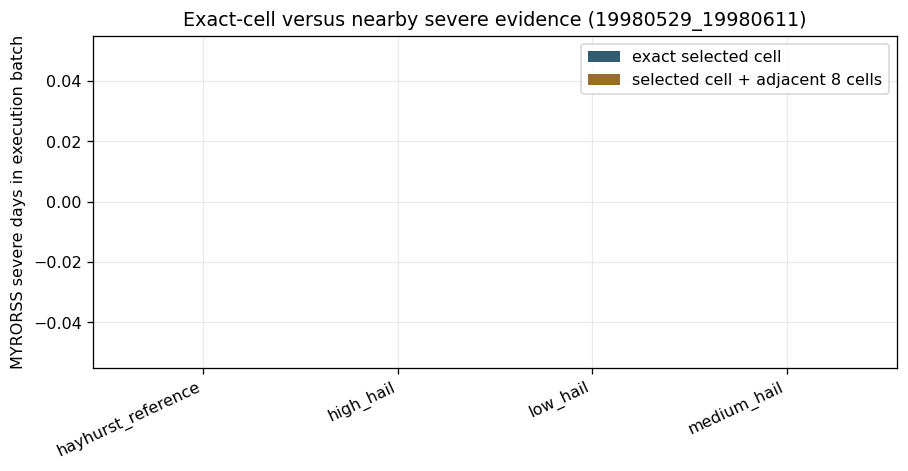

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.2))
plot_summary = summary.sort_values("role")
x = np.arange(len(plot_summary))
width = 0.38
ax.bar(x - width / 2, plot_summary["n_myrorss_hail_days"], width, color="#315c72", label="exact selected cell")
ax.bar(
    x + width / 2,
    plot_summary["n_days_with_neighbor_3x3_severe_mesh"],
    width,
    color="#9a6b2f",
    label="selected cell + adjacent 8 cells",
)
ax.set_xticks(x)
ax.set_xticklabels(plot_summary["role"], rotation=25, ha="right")
ax.set_ylabel("MYRORSS severe days in execution batch")
ax.set_title(f"Exact-cell versus nearby severe evidence ({BATCH_LABEL})")
ax.legend()
plt.tight_layout()
plt.show()

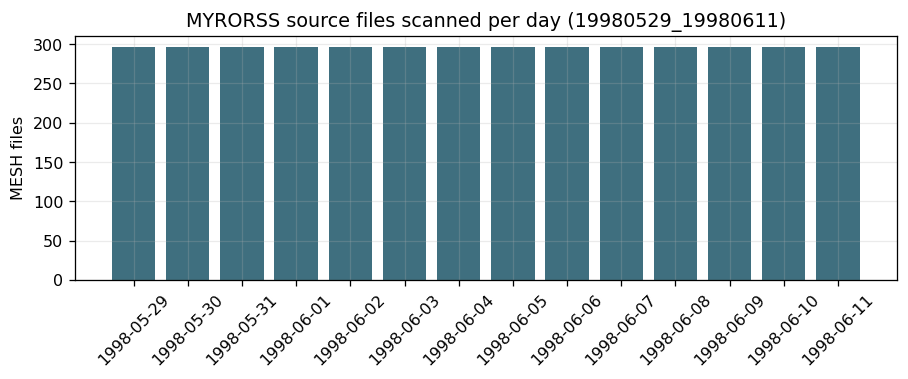

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.bar(day_manifest["date"], day_manifest["n_source_files"], color="#3f6f7f")
ax.set_title(f"MYRORSS source files scanned per day ({BATCH_LABEL})")
ax.set_ylabel("MESH files")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

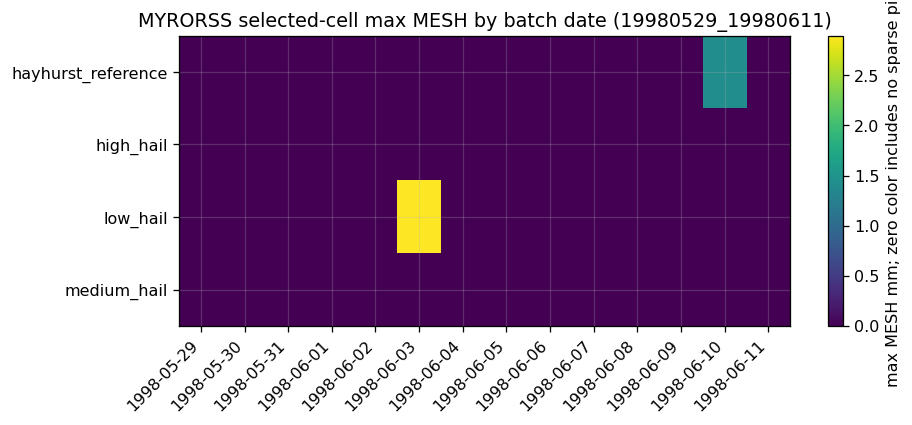

In [11]:
heat = panel.pivot(index="role", columns="date", values="mesh_max_mm")
fig, ax = plt.subplots(figsize=(max(7, len(heat.columns) * 0.6), 3.8))
im = ax.imshow(heat.fillna(0), aspect="auto", cmap="viridis")
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=45, ha="right")
ax.set_title(f"MYRORSS selected-cell max MESH by batch date ({BATCH_LABEL})")
fig.colorbar(im, ax=ax, label="max MESH mm; zero color includes no sparse pixel")
plt.tight_layout()
plt.show()

**Takeaway.** The useful readout here is not "what is the final rate?" It is "does the batch produce
explicit date rows, source-file QA, exact-cell evidence, and nearby-cell diagnostics with the same contract
we can later reconcile across all batches?"

## 8 - Write artifacts

These outputs are named by batch date range. Re-running the same window overwrites the same artifacts.

In [12]:
day_manifest.to_csv(DAY_MANIFEST_CSV, index=False)
panel.to_csv(DAILY_PANEL_CSV, index=False)
summary.to_csv(SUMMARY_CSV, index=False)

metadata = {
    "version": OUTPUT_VERSION,
    "hazard": "hail",
    "source": "MYRORSS",
    "source_product": "MESH/00.25",
    "stage": "M0 selected-cell chronological full-record batch",
    "selected_cells_path": str(SELECTED_CELLS_CSV.relative_to(ROOT)),
    "raw_cache_dir": str(RAW_MYRORSS_DIR.relative_to(ROOT)),
    "full_record_candidate_window": {
        "start": FULL_RECORD_CANDIDATE_START.date().isoformat(),
        "end": FULL_RECORD_CANDIDATE_END.date().isoformat(),
        "note": "Current working MYRORSS MESH candidate window; extend only after source-availability check.",
    },
    "execution_batch": {
        "batch_label": BATCH_LABEL,
        "start": BATCH_START.date().isoformat(),
        "end": BATCH_END.date().isoformat(),
        "n_days": int(len(BATCH_DATE_RANGE)),
        "date_selection": "chronological date range, not report-guided",
        "default_proof_batch": bool(
            BATCH_START == pd.Timestamp(DEFAULT_BATCH_START)
            and BATCH_END == pd.Timestamp(DEFAULT_BATCH_END)
        ),
    },
    "scan_coverage": {
        "n_source_files_total": int(day_manifest["n_source_files"].sum()),
        "n_empty_source_files_total": int(day_manifest["n_empty_source_files"].sum()),
        "n_read_failures_total": int(day_manifest["n_read_failures"].sum()),
        "n_days_with_source_files": int((day_manifest["n_source_files"] > 0).sum()),
        "n_days_without_source_files": int((day_manifest["n_source_files"] == 0).sum()),
    },
    "outputs": {
        "batch_plan_csv": str(BATCH_PLAN_CSV.relative_to(ROOT)),
        "day_manifest_csv": str(DAY_MANIFEST_CSV.relative_to(ROOT)),
        "daily_panel_csv": str(DAILY_PANEL_CSV.relative_to(ROOT)),
        "summary_csv": str(SUMMARY_CSV.relative_to(ROOT)),
    },
    "allowed_use": [
        "selected-cell MYRORSS chronological batch QA",
        "building toward a complete 1998-2011 selected-cell evidence panel",
        "exact-cell versus 3x3-neighborhood spatial diagnostics",
        "source-file coverage and no-data accounting",
    ],
    "not_allowed_use": [
        "final annual frequency estimate until full record batches are complete",
        "final MYRORSS climatology",
        "MRMS replacement",
        "reportable EAL/PML/VaR/TVaR input",
    ],
    "caveats": [
        "This batch may be much shorter than the full MYRORSS era.",
        "MYRORSS and MRMS are not assumed homogeneous.",
        "MYRORSS sparse-grid pixels do not provide the same denominator as dense MRMS daily tiles.",
        "3x3-neighborhood diagnostics are QA context only, not the selected-cell event definition.",
        "MESH bias and tail treatment remain unresolved.",
    ],
}
METADATA_JSON.write_text(json.dumps(metadata, indent=2) + "\n")

print("wrote:", BATCH_PLAN_CSV.relative_to(ROOT))
print("wrote:", DAY_MANIFEST_CSV.relative_to(ROOT))
print("wrote:", DAILY_PANEL_CSV.relative_to(ROOT))
print("wrote:", SUMMARY_CSV.relative_to(ROOT))
print("wrote:", METADATA_JSON.relative_to(ROOT))

wrote: data/hazard_conus_grid/hail/myrorss_m0_selected_cell_full_record_batch_plan_v2026_06_16.csv
wrote: data/hazard_conus_grid/hail/myrorss_m0_selected_cell_full_record_day_manifest_19980529_19980611_v2026_06_16.csv
wrote: data/hazard_conus_grid/hail/myrorss_m0_selected_cell_full_record_daily_panel_19980529_19980611_v2026_06_16.csv
wrote: data/hazard_conus_grid/hail/myrorss_m0_selected_cell_full_record_summary_19980529_19980611_v2026_06_16.csv
wrote: data/hazard_conus_grid/hail/myrorss_m0_selected_cell_full_record_metadata_19980529_19980611_v2026_06_16.json


## 9 - Next step

This notebook now defines the batch contract. The next operational step is **not automatically** to run the
whole MYRORSS candidate window. First document the source-promotion gate: coverage denominator, exact target
versus neighborhood QA, MRMS/MYRORSS comparability, MESH bias status, event/frequency definition, and tail
treatment.

After that, additional planned batches can be run deliberately, reconciled, and only then compared against
the MRMS pilot before any full-CONUS fanout.